# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.12.12 | numpy 2.5.3


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [2]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`.

    Keys, exactly these five:
        'dtype'    the element type, as a string (use str(...) on the dtype)
        'shape'    the shape, as a tuple
        'ndim'     the number of dimensions, as an int
        'size'     the total number of elements, as an int
        'nbytes'   the total number of bytes occupied by the data, as an int

    No allocation and no copying: read the attributes off `arr`.
    """
    return {
        "dtype": str(arr.dtype),
        "shape": arr.shape,
        "ndim": arr.ndim,
        "size": arr.size,
        "nbytes": arr.nbytes,
    }

In [3]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [4]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.

    The body below is the broken version. Fix it.
    """
    middle = arr[start:stop].copy()
    middle[:] = 0
    return middle

In [5]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [6]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.

    For each column j:  out[:, j] = (matrix[:, j] - mean_j) / sd_j

    Use the population standard deviation (NumPy's default, ddof=0).
    The result has the same shape as `matrix`. Do not modify `matrix`.
    Use broadcasting; do not write a `for` loop over the columns.
    """
    return (matrix - matrix.mean(axis=0)) / matrix.std(axis=0)

In [7]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [8]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.

    Keys and contents:
        'per_column_mean'  one value per COLUMN, shape (n_columns,)
        'per_row_sum'      one value per ROW,    shape (n_rows,)
        'per_row_max'      one value per ROW,    shape (n_rows,)
        'grand_total'      the sum of every element, a scalar float

    Return NumPy arrays for the first three and a Python/NumPy float for
    the last.
    """
    return {
        "per_column_mean": matrix.mean(axis=0),
        "per_row_sum": matrix.sum(axis=1),
        "per_row_max": matrix.max(axis=1),
        "grand_total": float(matrix.sum()),
    }

In [9]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [10]:
for label, total in [("_tall.sum()", _tall.sum()),
                     ("_tall.sum(axis=0)", _tall.sum(axis=0)),
                     ("_tall.sum(axis=1)", _tall.sum(axis=1))]:
    print(f"{label:18s} shape {np.shape(total)}")

print("\nper-feature mean, _tall.mean(axis=0):", np.round(_tall.mean(axis=0), 4))

_tall.sum()        shape ()
_tall.sum(axis=0)  shape (4,)
_tall.sum(axis=1)  shape (50,)

per-feature mean, _tall.mean(axis=0): [-0.1604 -0.0162  0.1642 -0.1834]


**Your answer:**

`_tall` has shape (50, 4): 50 rows (samples) and 4 columns (features). `_tall.sum()` has no axis, so it adds up all 200 numbers and returns a scalar with shape `()`. `_tall.sum(axis=0)` returns shape `(4,)` and `_tall.sum(axis=1)` returns shape `(50,)`.

The `axis` argument names the axis that gets **collapsed**, not the one that survives. Axis 0 is the row index, so `axis=0` walks down the 50 rows and squeezes them into one number. That happens separately in every column, so four columns leave four numbers. `axis=1` does the same thing across the 4 columns of each row, which leaves one number per row, i.e. 50.

For "the average value of each feature across all samples" I would use `_tall.mean(axis=0)`. A feature is a column, and averaging across samples means collapsing the rows. That gives one value per feature, here `[-0.1604, -0.0162, 0.1642, -0.1834]`. All four are close to 0, as expected for standard normal draws with only 50 samples.

## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [11]:
def sigma_outliers(sample, k=3.0):
    """Flag the values of `sample` that lie more than k standard deviations
    from the sample mean.

    Use the mean and standard deviation OF THE SAMPLE itself, not assumed
    values, and NumPy's default ddof=0 for the standard deviation.

    Return a tuple (mask, values):
        mask    a boolean array, the same shape as `sample`, True where the
                value is an outlier
        values  the outlying values themselves, in their original order

    Build the mask with a vectorised comparison; do not loop.
    """
    mask = np.abs(sample - sample.mean()) > k * sample.std()
    return mask, sample[mask]

In [12]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.3100%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [13]:
_theory = {1: 0.3173, 2: 0.0455, 3: 0.0027, 4: 0.000063, 5: 0.00000057}
print(f"{'k':>2} {'flagged':>8} {'observed':>10} {'expected count':>15}")
for k, frac in _theory.items():
    flagged = sigma_outliers(_normal, k=k)[0].sum()
    print(f"{k:>2} {flagged:>8} {flagged / _normal.size:>10.4%} {frac * _normal.size:>15.3f}")

 k  flagged   observed  expected count
 1     3163   31.6300%        3173.000
 2      454    4.5400%         455.000
 3       31    0.3100%          27.000
 4        2    0.0200%           0.630
 5        0    0.0000%           0.006


**Your answer:**

Counts at each threshold on the 10 000-point sample (expected count from the normal distribution in brackets): k=1: 3163 (3173), k=2: 454 (455), k=3: 31 (27), k=4: 2 (0.63), k=5: 0 (0.006). Up to k=2 the observed fractions (31.63 %, 4.54 %) match the theory almost exactly, because there are thousands or hundreds of points to count. At k=3 the match gets rougher (31 vs 27), because now only about thirty points are involved. At k=4 the expected count is below one point, so seeing 2 is just chance, and at k=5 we see 0 when the expectation is 0.006.

So from k=4 onwards the sample no longer has enough data to estimate the tail rate at all: 10 000 points cannot resolve a probability of 0.0063 %, and you would need millions of draws for that. The consequence for outlier detection is that a very large k does not make the rule "stricter" in a useful way. It mostly flags nothing, and when it does flag something we cannot tell whether that point is unusual or just the one-in-a-million value the distribution is allowed to produce. The k is a choice and it has to fit the sample size.

A situation where deleting a point is justified: a body-temperature dataset has a reading of 3.6 °C next to thousands of values around 36.6 °C. It is clearly a missing decimal digit, or a sensor that was not attached. The justification is not that the point is more than 3σ away. It has to come from the measurement process: a physically impossible value, a device log showing a fault at that time, or a record that it was typed by hand. Without that kind of evidence the point is just a rare value and should stay.

## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [14]:
def mean_ignoring_nan(sample):
    """Return the mean of the non-missing values of `sample`.

    Equivalent to np.nanmean, but you must implement it with np.isnan and
    boolean masking rather than calling any nan-aware NumPy reduction.

    If every value is missing, return np.nan.
    """
    present = sample[~np.isnan(sample)]
    if present.size == 0:
        return np.nan
    return present.sum() / present.size

In [15]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [16]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes.

    For each n in `sizes`, draw n values from normal(true_mu, true_sigma)
    using `generator`, and record the sample mean and the UNBIASED sample
    standard deviation (ddof=1).

    Draw the samples in the order the sizes are given, taking every sample
    from the same `generator` object, so that the result is reproducible
    for a given seed.

    Return a dict with three keys, each a NumPy array of len(sizes):
        'n'          the sample sizes, as given
        'mu_hat'     the estimated means
        'sigma_hat'  the estimated standard deviations
    """
    samples = [generator.normal(true_mu, true_sigma, n) for n in sizes]
    return {
        "n": np.array(sizes),
        "mu_hat": np.array([s.mean() for s in samples]),
        "sigma_hat": np.array([s.std(ddof=1) for s in samples]),
    }

In [17]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [18]:
_mu_by_seed = np.array([
    recover_parameters(2.0, 5.0, [100], np.random.default_rng(seed))["mu_hat"][0]
    for seed in [0, 1, 2, 3, 4]
])
print("(a) mu_hat at n=100, seeds 0..4:", np.round(_mu_by_seed, 4))
print(f"    spread: min {_mu_by_seed.min():.4f}, max {_mu_by_seed.max():.4f}, "
      f"sd {_mu_by_seed.std(ddof=1):.4f}   (theory sigma/sqrt(n) = {5.0 / np.sqrt(100):.4f})")

_fixed = recover_parameters(2.0, 5.0, [100, 10_000], np.random.default_rng(0))
_errors = np.abs(_fixed["mu_hat"] - 2.0)
for n, mu, err in zip(_fixed["n"], _fixed["mu_hat"], _errors):
    print(f"(b) n = {n:6,}  mu_hat = {mu:.4f}  |error| = {err:.4f}  "
          f"(standard error sigma/sqrt(n) = {5.0 / np.sqrt(n):.4f})")
print(f"    error ratio n=100 / n=10000: {_errors[0] / _errors[1]:.2f}   "
      f"(square-root rule predicts sqrt(100) = 10)")

(a) mu_hat at n=100, seeds 0..4: [2.4055 1.6319 1.9579 1.6911 1.6835]
    spread: min 1.6319, max 2.4055, sd 0.3232   (theory sigma/sqrt(n) = 0.5000)
(b) n =    100  mu_hat = 2.4055  |error| = 0.4055  (standard error sigma/sqrt(n) = 0.5000)
(b) n = 10,000  mu_hat = 2.0219  |error| = 0.0219  (standard error sigma/sqrt(n) = 0.0500)
    error ratio n=100 / n=10000: 18.55   (square-root rule predicts sqrt(100) = 10)


**Your answer:**

(a) With n = 100 and seeds 0 to 4 the estimates of mu were 2.4055, 1.6319, 1.9579, 1.6911 and 1.6835. They range from 1.63 to 2.41, with a standard deviation of 0.32 between them. The theoretical standard error is sigma/sqrt(n) = 5/10 = 0.5. So they vary by roughly half a unit around the true value 2.0, and five draws are not enough to pin that spread down precisely.

(b) With seed 0 and sizes [100, 10 000] the estimates were 2.4055 (error 0.4055) and 2.0219 (error 0.0219).

The seed decides **which** sample we get. It picks one particular set of random numbers, so the same seed always gives the same estimate. The sample size decides **how precise** the estimate is. Its typical error is sigma/sqrt(n) no matter which seed produced it. A bigger seed number does not give a better answer: seed 4 is not "more random" than seed 0, it is just a different sample. Re-running with a new seed only shows one more draw from the same sampling distribution. That is useful for seeing how much the estimate wobbles (which is what part (a) did), but it does not bring you closer to the truth the way more data does. An error of 0.4 at n = 100 is not a bug. It is smaller than one standard error (0.5), so it is a completely ordinary result.

Scaling: n went up 100 times and the error went from 0.4055 to 0.0219, i.e. about 18.55 times smaller. The square-root rule from Practice 1 §4.6 predicts sqrt(100) = 10 times smaller on average. One pair of errors is noisy (seed 0 happened to give a large error at n = 100), but the order of magnitude agrees with the 1/sqrt(n) rule. The standard errors themselves, 0.5 and 0.05, differ by exactly 10.

## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [19]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw `n` points from a 2-D normal centred at the origin with the given
    marginal standard deviations and correlation.

    Build the covariance matrix yourself from the three parameters:

        [[ sd_x**2,                      correlation*sd_x*sd_y ],
         [ correlation*sd_x*sd_y,        sd_y**2               ]]

    Draw from it with generator.multivariate_normal.

    Return a tuple (points, covariance):
        points      shape (n, 2)
        covariance  the 2x2 matrix you built, shape (2, 2)
    """
    off_diagonal = correlation * sd_x * sd_y
    covariance = np.array([[sd_x**2, off_diagonal],
                           [off_diagonal, sd_y**2]])
    points = generator.multivariate_normal([0.0, 0.0], covariance, size=n)
    return points, covariance

In [20]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [21]:
def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes).

    Both clouds: sd_x = sd_y = 2.0, n = 2000, drawn with `generator`
    via correlated_cloud from Task 8.
    Left panel  correlation 0.0.
    Right panel correlation 0.9.

    Each Axes must have set_xlabel, set_ylabel, set_title and an equal
    aspect ratio. The Figure must have a suptitle.

    Return the Figure and the array of two Axes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
    for ax, correlation in zip(axes, [0.0, 0.9]):
        points, _ = correlated_cloud(2.0, 2.0, correlation, 2000, generator)
        ax.scatter(points[:, 0], points[:, 1], s=4, alpha=0.3)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"correlation = {correlation}")
        ax.set_aspect("equal")
    fig.suptitle("Same marginal spreads (sd = 2), different correlation")
    fig.tight_layout()
    return fig, axes

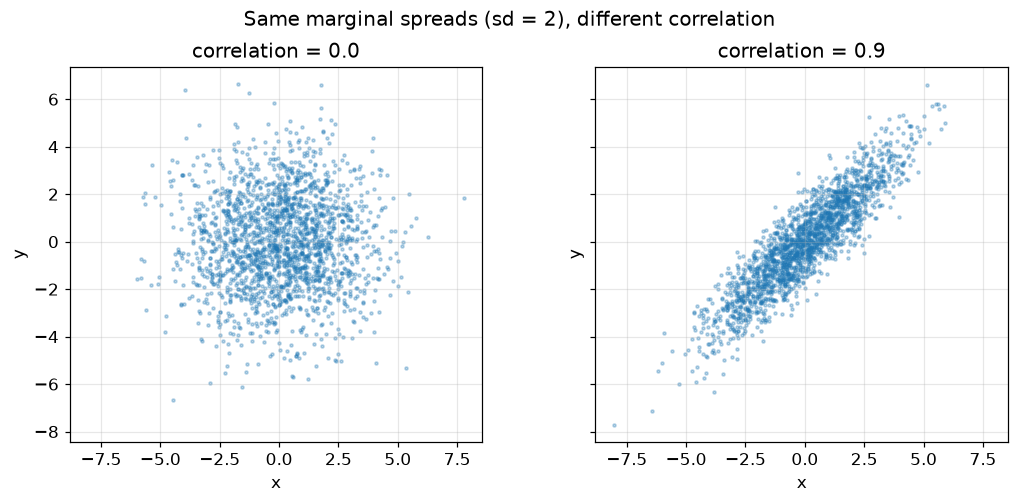

Task 9 passed.


In [22]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()
print("Task 9 passed.")

### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

correlation +0.0: sd(x) = 2.014  sd(y) = 1.991  measured r = +0.013
correlation +0.9: sd(x) = 1.998  sd(y) = 2.007  measured r = +0.899
correlation -0.9: sd(x) = 1.960  sd(y) = 1.992  measured r = -0.895


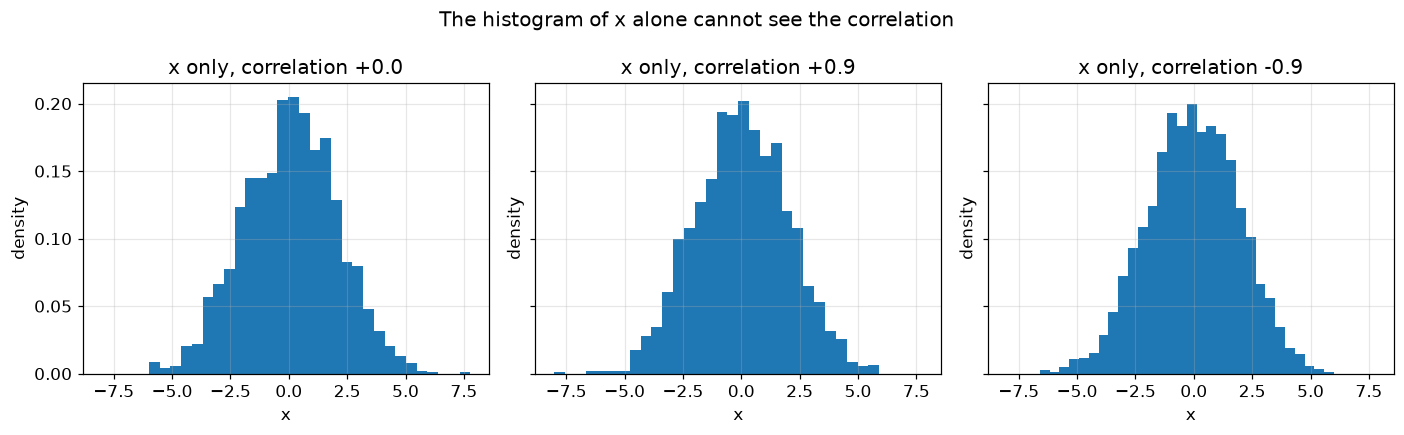

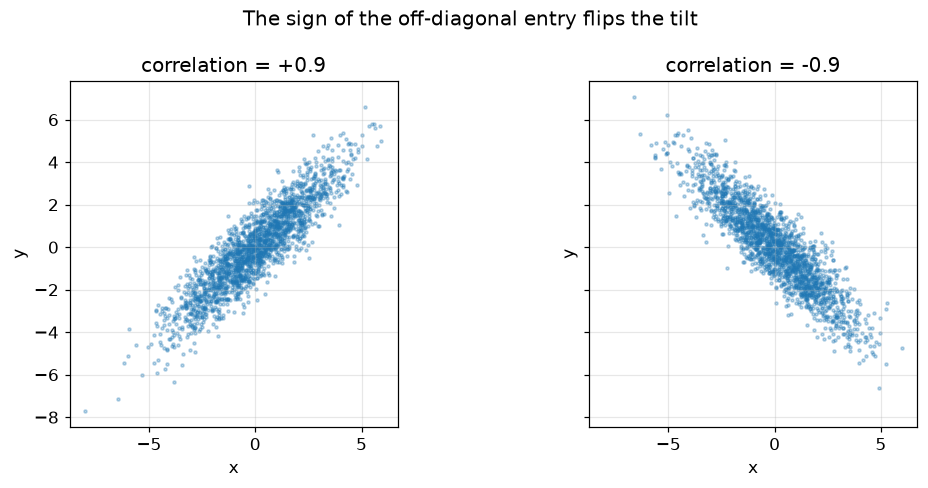

In [23]:
_q4_rng = np.random.default_rng(3)
_clouds = {rho: correlated_cloud(2.0, 2.0, rho, 2000, _q4_rng)[0] for rho in [0.0, 0.9, -0.9]}

for rho, pts in _clouds.items():
    print(f"correlation {rho:+.1f}: sd(x) = {pts[:, 0].std():.3f}  sd(y) = {pts[:, 1].std():.3f}  "
          f"measured r = {np.corrcoef(pts.T)[0, 1]:+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, (rho, pts) in zip(axes, _clouds.items()):
    ax.hist(pts[:, 0], bins=30, density=True)
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.set_title(f"x only, correlation {rho:+.1f}")
fig.suptitle("The histogram of x alone cannot see the correlation")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for ax, rho in zip(axes, [0.9, -0.9]):
    pts = _clouds[rho]
    ax.scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"correlation = {rho:+.1f}")
    ax.set_aspect("equal")
fig.suptitle("The sign of the off-diagonal entry flips the tilt")
fig.tight_layout()
plt.show()

**Your answer:**

With the correlation changed from +0.9 to -0.9, the cloud keeps the same elongated ellipse shape but tilts the other way: it runs from top-left to bottom-right instead of bottom-left to top-right. The measured correlations came out as +0.899 and -0.895.

What does not change is the spread of each variable on its own. For correlation 0.0, +0.9 and -0.9 I got sd(x) = 2.014, 1.998 and 1.960, and sd(y) = 1.991, 2.007 and 1.992. All of them are close to the requested 2.0, because the diagonal of the covariance matrix (sd_x² = sd_y² = 4) is the same in all three cases. Only the off-diagonal entry changed. The three histograms of the x coordinate alone (the first extra figure above) look practically the same, each one the same bell shape centred at 0 with the same width. I could not tell from them which one came from the correlated cloud and which from the independent one, or what the sign of the correlation was.

Consequence: looking at variables one at a time, through histograms or per-column means and standard deviations, cannot show how they are related to each other, so relationships have to be checked with joint views such as scatter plots or the correlation matrix.

## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [24]:
def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.

    One Figure, len(bin_counts) Axes in a single row. Panel i uses
    bins=bin_counts[i] and the given `density` flag for every panel.

    Each Axes needs an x label, a y label, and a title naming its bin count.
    The y label must say 'density' when density is True and 'count' when it
    is False, because those are different quantities.

    Return (fig, axes).
    """
    fig, axes = plt.subplots(1, len(bin_counts), figsize=(4.5 * len(bin_counts), 4),
                             squeeze=False)
    axes = axes[0]
    for ax, bins in zip(axes, bin_counts):
        ax.hist(sample, bins=bins, density=density)
        ax.set_xlabel("value")
        ax.set_ylabel("density" if density else "count")
        ax.set_title(f"{bins} bins")
    fig.tight_layout()
    return fig, axes

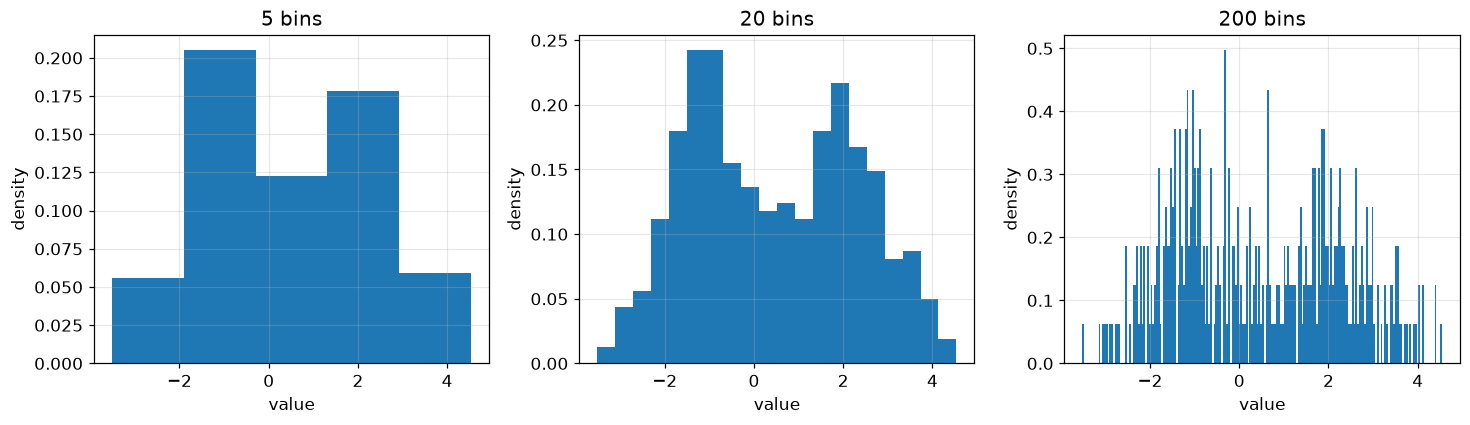

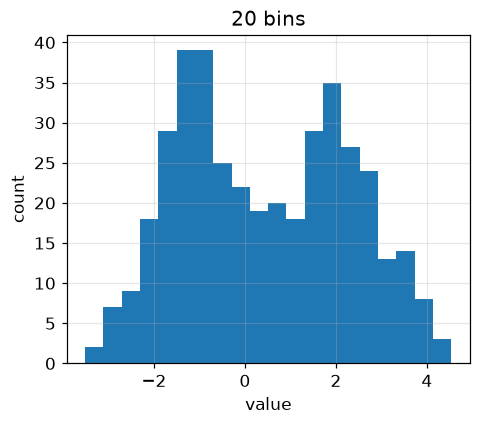

Task 10 passed.


In [25]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

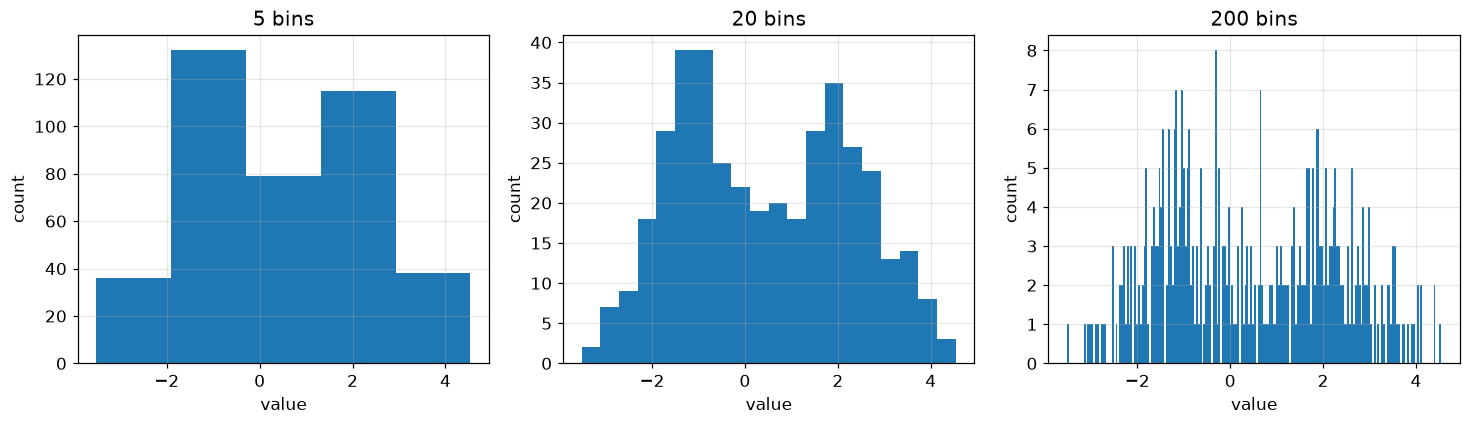

5 bins, density per bar: [0.056, 0.205, 0.123, 0.178, 0.059]
5 bins, bar centres     : [-2.71, -1.1, 0.51, 2.12, 3.73]
20 bins, density per bar: [0.012, 0.043, 0.056, 0.112, 0.18, 0.242, 0.242, 0.155, 0.137, 0.118, 0.124, 0.112, 0.18, 0.217, 0.168, 0.149, 0.081, 0.087, 0.05, 0.019]
20 bins, bar centres     : [-3.32, -2.91, -2.51, -2.11, -1.7, -1.3, -0.9, -0.5, -0.09, 0.31, 0.71, 1.11, 1.52, 1.92, 2.32, 2.73, 3.13, 3.53, 3.93, 4.34]
  5 bins: width 1.611  max count 132  max density 0.205  count/(n*width) = 0.205  area under density = 1.000
 20 bins: width 0.403  max count  39  max density 0.242  count/(n*width) = 0.242  area under density = 1.000
200 bins: width 0.040  max count   8  max density 0.497  count/(n*width) = 0.497  area under density = 1.000


In [26]:
_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=False)
plt.show()

for bins in [5, 20]:
    dens, edges = np.histogram(_mixture, bins=bins, density=True)
    print(f"{bins} bins, density per bar:", np.round(dens, 3).tolist())
    print(f"{bins} bins, bar centres     :", np.round((edges[:-1] + edges[1:]) / 2, 2).tolist())

for bins in [5, 20, 200]:
    counts, edges = np.histogram(_mixture, bins=bins)
    dens, _ = np.histogram(_mixture, bins=bins, density=True)
    width = edges[1] - edges[0]
    print(f"{bins:>3} bins: width {width:.3f}  max count {counts.max():>3}  max density {dens.max():.3f}  "
          f"count/(n*width) = {counts.max() / (_mixture.size * width):.3f}  "
          f"area under density = {(dens * width).sum():.3f}")

**Your answer:**

(a) The mixture has two components, at -1 and +2. With 20 bins the two peaks are clearly visible: one around -1 (density about 0.24) and one around +2 (about 0.22), with a dip to about 0.11 to 0.12 between them. With 5 bins each bar is 1.6 wide and the structure is mostly hidden. There are two taller bars (0.205 and 0.178) with a 0.12 bar between them, so you might guess two bumps, but it looks more like a single wide, flat distribution. At 200 bins the bars are only 0.04 wide and hold at most 8 points each, so the picture becomes a jagged comb that goes up to 0.50. The individual spikes at 200 bins are not real: they are counting noise from very small bins, and a different sample of 400 points would put them in different places.

(b) The raw counts and the densities have the same shape but different numbers: for example, the tallest bar at 5 bins is a count of 132 or a density of 0.205, and at 200 bins it is 8 or 0.497. `density=True` divides each count by (total number of points × bin width). For the 200-bin case that is 8 / (400 × 0.040) = 0.497, which matches. After this division the total area of the bars is 1 (I checked: 1.000 for all three bin counts), so the histogram becomes an estimate of the probability density. That is why samples of different sizes become comparable: with raw counts a sample of 10 000 points would have bars 25 times taller than a sample of 400 points from the same distribution, and the smaller one would look flat next to it. With densities both are scaled to area 1, so the same distribution gives the same heights and any difference in shape is real.

(c) My first question would be: "How many bins did you use, and does the double peak survive if you change the bin count (and how many points is it based on)?" Part (a) shows that the bin count alone can create or hide peaks, so a double peak that only appears at one bin setting, or with a small sample, is not evidence of two subgroups.

## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

In [27]:
# The data. Do not modify this cell.
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

print("mystery_sample is ready:", mystery_sample.shape)

mystery_sample is ready: (5000,)


shape (5000,) | dtype float64 | nbytes 40000 (39.1 KiB)
mean 10.6311  median 10.0925  sd 5.0650  min 2.5716  max 59.7279
mean - median = 0.5386


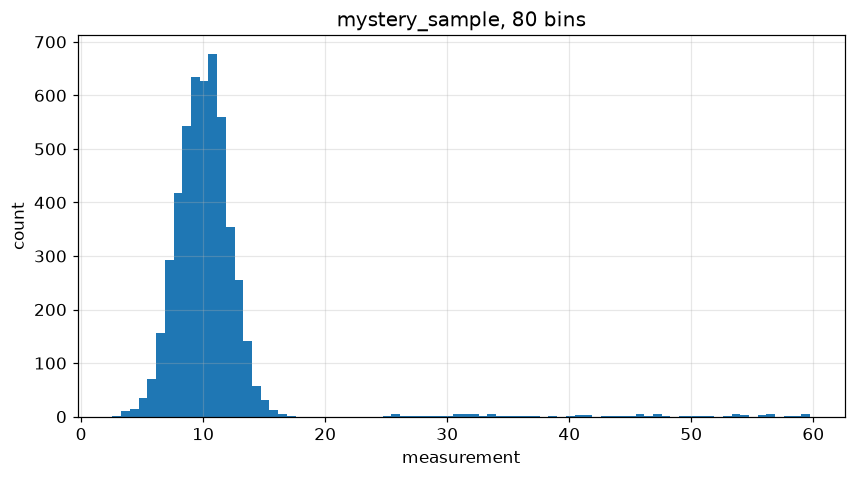

flagged at k=3: 94  (1.88%);  expected from a normal sample: 13.5
flagged values range: 25.93 .. 59.73
threshold: |x - 10.63| > 3 * 5.07 = 15.20  -> x > 25.83
values above 20 not flagged: 6
all points:      n 5000  mean 10.6311  sd 5.0650  median 10.0925
flagged removed: n 4906  mean 10.0210  sd 2.0930  median 10.0419
second pass of the 3-sigma rule on the cleaned sample flags 15 more


In [28]:
print("shape", mystery_sample.shape, "| dtype", mystery_sample.dtype,
      "| nbytes", mystery_sample.nbytes, f"({mystery_sample.nbytes / 1024:.1f} KiB)")

_m_mean, _m_median, _m_sd = mystery_sample.mean(), np.median(mystery_sample), mystery_sample.std()
print(f"mean {_m_mean:.4f}  median {_m_median:.4f}  sd {_m_sd:.4f}  "
      f"min {mystery_sample.min():.4f}  max {mystery_sample.max():.4f}")
print(f"mean - median = {_m_mean - _m_median:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(mystery_sample, bins=80, density=False)
ax.set_xlabel("measurement")
ax.set_ylabel("count")
ax.set_title("mystery_sample, 80 bins")
plt.show()

_m_mask, _m_values = sigma_outliers(mystery_sample, k=3.0)
print(f"flagged at k=3: {_m_mask.sum()}  ({_m_mask.mean():.2%});  "
      f"expected from a normal sample: {0.0027 * mystery_sample.size:.1f}")
print(f"flagged values range: {_m_values.min():.2f} .. {_m_values.max():.2f}")
print(f"threshold: |x - {_m_mean:.2f}| > 3 * {_m_sd:.2f} = {3 * _m_sd:.2f}  "
      f"-> x > {_m_mean + 3 * _m_sd:.2f}")
print(f"values above 20 not flagged: {((mystery_sample > 20) & ~_m_mask).sum()}")

_kept = mystery_sample[~_m_mask]
print(f"all points:      n {mystery_sample.size}  mean {_m_mean:.4f}  sd {_m_sd:.4f}  median {_m_median:.4f}")
print(f"flagged removed: n {_kept.size}  mean {_kept.mean():.4f}  sd {_kept.std():.4f}  median {np.median(_kept):.4f}")

_again_mask, _ = sigma_outliers(_kept, k=3.0)
print(f"second pass of the 3-sigma rule on the cleaned sample flags {_again_mask.sum()} more")

**Your write-up:**

**What the data is.** The sample is a 1-D array of 5000 float64 values and takes 40 000 bytes (39.1 KiB, 8 bytes per value). The mean is 10.63, the median 10.09, the standard deviation 5.07, the minimum 2.57 and the maximum 59.73. The mean is 0.54 above the median. Even before plotting, that points to a skewed distribution with a long right tail: a small number of large values pulls the mean up, while the median, which only depends on the middle of the data, barely moves. The maximum of 59.73 is almost 10 standard deviations above the mean, which is also not what a single normal distribution would produce.

**Histogram.** I used 80 bins: with 5000 points that still leaves many points per bin in the main part, but the bins are narrow enough (about 0.7 units) to show a sparse tail separately instead of merging it into the bulk. The plot shows one tight, roughly bell-shaped group centred near 10, going from about 3 to 17. After that there is an empty gap from about 17 to 25, and then a thin, flat scatter of isolated points spread fairly evenly from 25 all the way to 60. It does not look like a tail that thins out gradually. It looks like a separate group of values.

**3-sigma rule.** With k = 3 the threshold is |x - 10.63| > 15.20, i.e. x > 25.83. It flags 94 points (1.88 %), all between 25.93 and 59.73. A normal sample of this size would give about 0.27 % × 5000 ≈ 13.5 points, so we flag roughly seven times more than normal noise would explain. At the same time the rule does not catch the whole far group: 6 points between 25 and 25.83 sit in the same flat cluster but fall just under the threshold. The reason is that the outliers themselves inflate the standard deviation (5.07), which pushes the threshold up.

**With and without the flagged points.** With all 5000 points: mean 10.63, sd 5.07, median 10.09. With the 94 flagged points removed (4906 left): mean 10.02, sd 2.09, median 10.04. The median hardly changes, but the standard deviation falls to less than half. When I run the 3-sigma rule again on the cleaned data, it flags another 15 points, because the sd is now much smaller. So repeating the rule would keep eating into the data, and it never settles on an obviously "clean" set.

**Should they be removed?** Not only because the rule flagged them. The numbers show that there are two groups (about 98 % of the values near 10 and about 2 % spread flat over 25 to 60), but they cannot tell us which group is "wrong". What I would need to know is how the data was measured. If the instrument has a known valid range, for example it cannot read above 20, or the far values match a known failure (a sensor saturating, a unit mix-up, a different device or operator, a logging error on particular dates), then those values are measurement errors. Then it is right to remove all of them, including the 6 the rule missed, and report the clean mean of about 10.0 and sd of about 2.1. But if the measurement process is fine and the high values are real events (for example, rare but genuine high readings from a different subpopulation), deleting them would hide exactly the most interesting part of the data. In that case I would keep them and either report the two groups separately or use robust statistics such as the median. Without that information I would keep the data, report both versions of the mean and standard deviation, and state clearly that the conclusion depends on whether the values above 25 are real.

## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.